In [2]:

!pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# glob
from glob import glob

# computer vision library
import cv2
# visualization
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
fpath = glob('./crop_data/female/*.jpg')
mpath = glob('./crop_data/male/*.jpg')

In [5]:
df_female = pd.DataFrame(fpath, columns=['filepath'])
df_female['gender'] = 'female'

df_male = pd.DataFrame(mpath, columns=['filepath'])
df_male['gender'] = 'male'

df = pd.concat((df_female, df_male), axis=0)

df.head()

,filepath,gender
0,./crop_data/female\female_0.jpg,female
1,./crop_data/female\female_1.jpg,female
2,./crop_data/female\female_100.jpg,female
3,./crop_data/female\female_1002.jpg,female
4,./crop_data/female\female_1005.jpg,female


In [6]:
df.tail()

,filepath,gender
2170,./crop_data/male\male_994.jpg,male
2171,./crop_data/male\male_996.jpg,male
2172,./crop_data/male\male_997.jpg,male
2173,./crop_data/male\male_998.jpg,male
2174,./crop_data/male\male_999.jpg,male


In [7]:
df.shape

(4761, 2)

In [8]:
def get_size(path):
    img = cv2.imread(path)
    return img.shape[0]

print(get_size('./crop_data/male\male_994.jpg'))

122


In [9]:
df['dimension'] = df['filepath'].apply(get_size)  # store dimension of image in this columns
df

,filepath,gender,dimension
0,./crop_data/female\female_0.jpg,female,273
1,./crop_data/female\female_1.jpg,female,182
2,./crop_data/female\female_100.jpg,female,122
3,./crop_data/female\female_1002.jpg,female,122
4,./crop_data/female\female_1005.jpg,female,182
...,...,...,...
2170,./crop_data/male\male_994.jpg,male,122
2171,./crop_data/male\male_996.jpg,male,54
2172,./crop_data/male\male_997.jpg,male,122
2173,./crop_data/male\male_998.jpg,male,81


#### Exploratory Data Analysis
1. Distribution of Male and Female
 - Bar Chart
 - Pie Chart
2. What Distribution of size of all Images
 - Histogram
 - Box Plot
 - Split by “Gender”
3. Make the decision of width & height to resize using above chart.
4. Remove the few images that are having very less size

In [10]:
dist_gender = df['gender'].value_counts()
dist_gender

gender
female    2586
male      2175
Name: count, dtype: int64

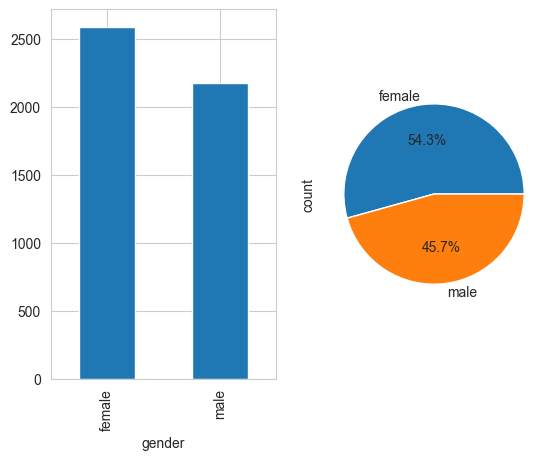

In [11]:
fig,ax = plt.subplots(nrows=1, ncols=2)

dist_gender.plot(kind='bar', ax=ax[0])
dist_gender.plot(kind='pie', autopct='%1.1f%%', ax=ax[1])
plt.show()

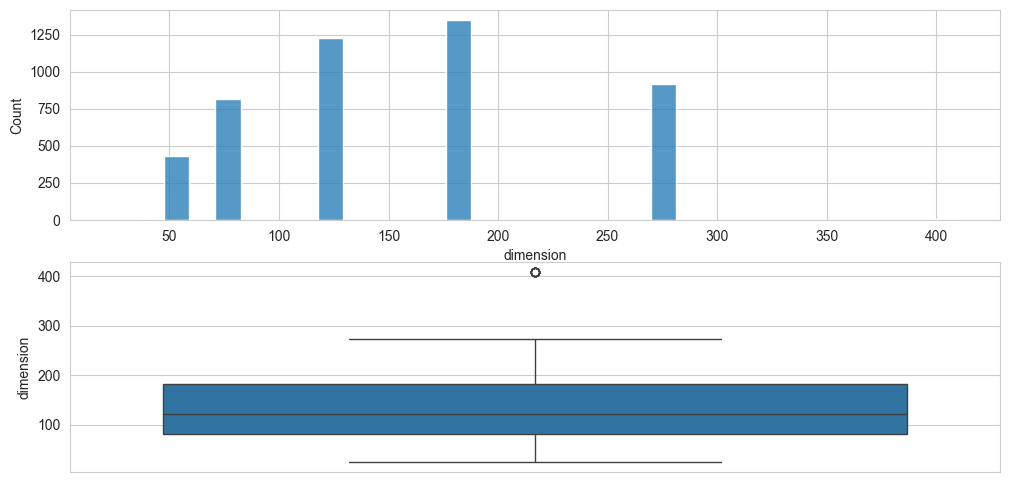

In [12]:
# What Distribution of size of all Images
# Histogram
# Box Plot
# Split by “Gender”
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
sns.histplot(df['dimension'])
plt.subplot(2,1,2)
sns.boxplot(df['dimension'])
plt.show()

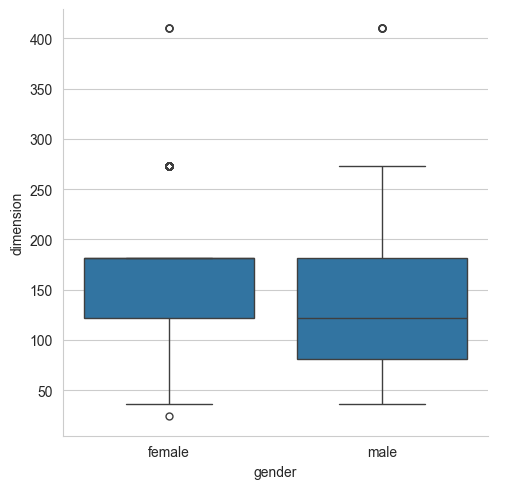

In [13]:
sns.catplot(data=df, x='gender', y='dimension', kind='box')

1. We have almost equal distrbution of gender (numbers)
2. Most of the images are having dimension more than 60
3. Female most of the female images are HD compare to male images

---
- **Consider the image with dimensions more than 60**
- **Resize all the the image into 100 x 100**

In [14]:
df_filter = df.query('dimension > 60').copy()
df_filter.shape

(4321, 3)

In [15]:
df_filter['gender'].value_counts(normalize=True)

gender
female    0.551956
male      0.448044
Name: proportion, dtype: float64

In [16]:
def structuring(path):
    try:
        # step - 1: read image
        img = cv2.imread(path) # BGR
        # step - 2: convert into grayscale
        gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        # step -3: resize into 100 x 100 array

        size = gray.shape[0]
        if size >= 100:
            # cv2.INTER_AREA (SHINK)
            gray_resize = cv2.resize(gray,(100,100),cv2.INTER_AREA)
        else:
            # cv2.INTER_CUBIC (ENLARGE)
            gray_resize = cv2.resize(gray,(100,100),cv2.INTER_CUBIC)

        # step -4: Flatten Image (1x10,000)
        flatten_image = gray_resize.flatten()
        return flatten_image
    except:
        return None

In [17]:
df_filter['data'] = df_filter['filepath'].apply(structuring)  # convert all images into 100 x 100
df_filter.head()

,filepath,gender,dimension,data
0,./crop_data/female\female_0.jpg,female,273,"[200, 189, 188, 181, 184, 185, 179, 176, 189, ..."
1,./crop_data/female\female_1.jpg,female,182,"[31, 25, 35, 25, 31, 29, 30, 31, 34, 34, 49, 7..."
2,./crop_data/female\female_100.jpg,female,122,"[49, 49, 35, 34, 42, 40, 35, 39, 71, 62, 46, 4..."
3,./crop_data/female\female_1002.jpg,female,122,"[137, 128, 114, 96, 96, 95, 93, 114, 150, 163,..."
4,./crop_data/female\female_1005.jpg,female,182,"[234, 236, 231, 231, 231, 185, 142, 111, 52, 4..."


In [18]:
df_filter

,filepath,gender,dimension,data
0,./crop_data/female\female_0.jpg,female,273,"[200, 189, 188, 181, 184, 185, 179, 176, 189, ..."
1,./crop_data/female\female_1.jpg,female,182,"[31, 25, 35, 25, 31, 29, 30, 31, 34, 34, 49, 7..."
2,./crop_data/female\female_100.jpg,female,122,"[49, 49, 35, 34, 42, 40, 35, 39, 71, 62, 46, 4..."
3,./crop_data/female\female_1002.jpg,female,122,"[137, 128, 114, 96, 96, 95, 93, 114, 150, 163,..."
4,./crop_data/female\female_1005.jpg,female,182,"[234, 236, 231, 231, 231, 185, 142, 111, 52, 4..."
...,...,...,...,...
2168,./crop_data/male\male_991.jpg,male,273,"[120, 95, 110, 84, 101, 153, 114, 145, 161, 16..."
2170,./crop_data/male\male_994.jpg,male,122,"[16, 18, 17, 16, 17, 16, 14, 15, 16, 19, 16, 1..."
2172,./crop_data/male\male_997.jpg,male,122,"[177, 179, 180, 181, 181, 182, 183, 183, 181, ..."
2173,./crop_data/male\male_998.jpg,male,81,"[37, 37, 37, 37, 38, 40, 40, 39, 39, 39, 39, 3..."


In [23]:
data = df_filter['data'].apply(pd.Series)
data

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,200,189,188,181,184,185,179,176,189,180,...,109,106,108,111,113,115,120,117,118,122
1,31,25,35,25,31,29,30,31,34,34,...,45,27,22,30,22,35,20,35,65,19
2,49,49,35,34,42,40,35,39,71,62,...,210,230,231,237,238,230,220,212,210,208
3,137,128,114,96,96,95,93,114,150,163,...,66,53,68,67,74,92,97,103,102,96
4,234,236,231,231,231,185,142,111,52,45,...,241,240,236,237,239,237,237,242,241,241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2168,120,95,110,84,101,153,114,145,161,164,...,114,117,124,126,130,137,137,134,123,112
2170,16,18,17,16,17,16,14,15,16,19,...,224,229,232,233,234,235,235,234,233,232
2172,177,179,180,181,181,182,183,183,181,180,...,143,143,141,137,139,144,151,158,166,172
2173,37,37,37,37,38,40,40,39,39,39,...,40,41,44,48,54,61,67,71,72,71


In [24]:
data.columns = [f"pixel_{i}" for i in data.columns]
data.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_9990,pixel_9991,pixel_9992,pixel_9993,pixel_9994,pixel_9995,pixel_9996,pixel_9997,pixel_9998,pixel_9999
0,200,189,188,181,184,185,179,176,189,180,...,109,106,108,111,113,115,120,117,118,122
1,31,25,35,25,31,29,30,31,34,34,...,45,27,22,30,22,35,20,35,65,19
2,49,49,35,34,42,40,35,39,71,62,...,210,230,231,237,238,230,220,212,210,208
3,137,128,114,96,96,95,93,114,150,163,...,66,53,68,67,74,92,97,103,102,96
4,234,236,231,231,231,185,142,111,52,45,...,241,240,236,237,239,237,237,242,241,241


#### Data Normalization

In [25]:
# since for 8 bit image max value is 255
# therefore we are dividing each and every pixel with 255
data = data/255.0

In [27]:
data['gender'] = df_filter['gender']

In [28]:
data.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_9991,pixel_9992,pixel_9993,pixel_9994,pixel_9995,pixel_9996,pixel_9997,pixel_9998,pixel_9999,gender
0,0.784314,0.741176,0.737255,0.709804,0.721569,0.725490,0.701961,0.690196,0.741176,0.705882,...,0.415686,0.423529,0.435294,0.443137,0.450980,0.470588,0.458824,0.462745,0.478431,female
1,0.121569,0.098039,0.137255,0.098039,0.121569,0.113725,0.117647,0.121569,0.133333,0.133333,...,0.105882,0.086275,0.117647,0.086275,0.137255,0.078431,0.137255,0.254902,0.074510,female
2,0.192157,0.192157,0.137255,0.133333,0.164706,0.156863,0.137255,0.152941,0.278431,0.243137,...,0.901961,0.905882,0.929412,0.933333,0.901961,0.862745,0.831373,0.823529,0.815686,female
3,0.537255,0.501961,0.447059,0.376471,0.376471,0.372549,0.364706,0.447059,0.588235,0.639216,...,0.207843,0.266667,0.262745,0.290196,0.360784,0.380392,0.403922,0.400000,0.376471,female
4,0.917647,0.925490,0.905882,0.905882,0.905882,0.725490,0.556863,0.435294,0.203922,0.176471,...,0.941176,0.925490,0.929412,0.937255,0.929412,0.929412,0.949020,0.945098,0.945098,female


In [31]:
data.isnull().sum()
data.sum()

np.int64(0)

In [ ]:
## remove the missing values
data.dropna(inplace=True)

In [32]:
data.shape

(4321, 10001)

In [42]:
import pickle
pickle.dump(data,open('./data/data_images_100_100.pickle',mode='wb'))

##### Example to practice missing values

In [33]:
import pandas as pd
import numpy as np

# DataFrame de ejemplo
df = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [np.nan, 6, 7, 8],
    'C': [9, 10, 11, np.nan]
})

print("DataFrame original:")
print(df)

DataFrame original:
     A    B     C
0  1.0  NaN   9.0
1  2.0  6.0  10.0
2  NaN  7.0  11.0
3  4.0  8.0   NaN


In [34]:
df.isnull()

,A,B,C
0,False,True,False
1,False,False,False
2,True,False,False
3,False,False,True


In [35]:
df.isnull().sum()

A    1
B    1
C    1
dtype: int64

In [37]:
df.isnull().sum().sum()

np.int64(3)

In [38]:
df.dropna(inplace=True)

In [39]:
df

,A,B,C
1,2.0,6.0,10.0


##### Flattening Example

In [40]:
import numpy as np
gray_resize = np.array(
    [[ 0,  1,  2],
     [10, 11, 12],
     [20, 21, 22]]
)
print("Original array:")
print(gray_resize)


Original array:
[[ 0  1  2]
 [10 11 12]
 [20 21 22]]


In [41]:
#Aplicar flatten
gray_resize.flatten()

array([ 0,  1,  2, 10, 11, 12, 20, 21, 22])